# FIP 15 — DA and NE task responses and their trial-by-trial coupling

How do DA and NE respond around the choice and outcome, by outcome and by RPE within an outcome,
and do their response sizes and peak latencies co-vary from trial to trial?

0. Per-trial measures and choice-aligned traces from Rachel's pipeline
1. Responses by outcome and by RPE
2. Trial-by-trial coupling of response size and peak latency
3. Figures, one per response window: 0.33–1 s (Rachel's), 0–0.5 s, 0.5–2 s and 0–2 s after the choice
4. Numbers

**Signals.** DA: dLight in lateral NAc (`latNAcc(X)-DA`). NE: GCaMP in LC noradrenergic axons
imaged in PL (`PL(X)-LCAxonCa`), i.e. axonal calcium. Both are `dff-bright_mc-iso-IRLS` dF/F at
20 Hz. The two indicators have different kinetics, so lags describe the recorded signals, not
timing in the brain.

**Data.** The CSV-curated `DANE_3channels_curated` and `DANE_4channels_curated` assets, one
hemisphere per animal (the side with more sessions), animals with at least 3 sessions; 97
sessions, 9 animals. Loaded with Rachel's `dummy_nwb.load`; no motion energy.

**Statistics.** Each measure is computed per session. Tables give, per animal, the number of
sessions, the median and range across sessions and, where a per-session test exists, the fraction
of sessions with p < 0.05 and the range of per-session p. Across animals: Wilcoxon signed-rank on
per-animal means; error bands are SEM over animals.

**Conventions.** Positive latency difference = NE later. Choice time and outcome time are the same
event (≤ 1 ms apart). Colors: DA vermillion, NE blue, rewarded orange, unrewarded grey, totals black.

## Setup

In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import fip_utils as fu
import stats_utils as st
import plot_utils as pu
from rachel_analysis_utils.nwb_utils import dummy_nwb
from aind_dynamic_foraging_data_utils import alignment
from aind_dynamic_foraging_basic_analysis.metrics import trial_metrics
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
TRIAL_CACHE = ("/root/capsule/scratch/fip_07/trial_tables.pkl" if IS_CO
               else "../../data/fip_07_cache/trial_tables.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

FS = 20.0                    # Hz, rate of the aligned traces
MIN_SESSIONS_PER_ANIMAL = 3

# ── Task responses (Rachel's pipeline) ───────────────────────────────────────
DATA_COL = "data_z_norm"
ALIGN = "choice_time_in_session"          # = outcome time in these sessions
CUE = "goCue_start_time_in_session"
WINDOWS = {                               # s after the choice / outcome
    "rachel": (0.33, 1.0),                # Rachel's add_AUC_and_rpe_slope window
    "early": (0.0, 0.5),
    "late": (0.5, 2.0),
    "full": (0.0, 2.0),
}
WINDOW_LABEL = {"rachel": "Rachel 0.33–1 s", "early": "early 0–0.5 s", "late": "late 0.5–2 s",
                "full": "full 0–2 s"}
PSTH_T = (-1.0, 3.0)                      # choice-aligned traces
LATENCY_WIN = (0.0, 1.5)                  # peak search after the go cue
MIN_PEAK_Z = 1.0                          # a latency counts only if the peak clears this (z above baseline)
MIN_RPE_SD = 0.05                         # sessions with flatter within-outcome RPE are left out of the RPE panels
QCH_BINS = ["Qch 0", "Qch 0.33", "Qch 0.66"]

# ── Colors ───────────────────────────────────────────────────────────────────
SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"]}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)"}
OUT_COLOR = {"rewarded": OKABE_ITO["orange"], "unrewarded": "0.45"}
TOTAL_COLOR = "k"
# RPE bins, ordered from lowest to highest RPE within each outcome
RPE_BIN_COLOR = {"rewarded": plt.cm.Oranges(np.linspace(0.35, 0.9, 3)),
                 "unrewarded": plt.cm.Greys(np.linspace(0.85, 0.35, 3))}

## 0. Data

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

inv = fu.inventory_pairs(asset_roots)
kept, side_table = fu.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)

SUBJECTS = sorted(kept["subject"].unique())
N_ANIMALS = len(SUBJECTS)
print(f"{len(kept)} sessions from {N_ANIMALS} animals")
side_table[side_table.kept]

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data


97 sessions from 9 animals


side,asset,L,R,side_used,n_used,kept
subject,,,,,,
800886,3ch,5,0,L,5,True
808054,4ch,1,16,R,16,True
809487,4ch,8,0,L,8,True
809491,4ch,20,0,L,20,True
815334,4ch,3,4,R,4,True
816212,4ch,8,0,L,8,True
816214,4ch,0,5,R,5,True
818585,3ch,8,0,L,8,True
818586,3ch,23,0,L,23,True


In [4]:
def per_animal(df, effect, p=None, z=None):
    """Per animal: sessions, median and range of `effect` across sessions, and per-session test summary.

    With `z` (a per-session z-score against a shift null) the median and range of z are given; the
    shift tests' p-values sit at their floor, so their range is not shown."""
    rows = []
    for subj, g in df.groupby("subject"):
        e = g[effect].dropna()
        r = dict(subject=subj, n_sessions=len(e), median=e.median(), min=e.min(), max=e.max())
        if p is not None:
            pv = g.loc[e.index, p]
            r["frac_p_lt_05"] = (pv < 0.05).mean()
            if z is None:
                r.update(p_min=pv.min(), p_max=pv.max())
        if z is not None:
            zv = g.loc[e.index, z]
            r.update(z_median=zv.median(), z_min=zv.min(), z_max=zv.max())
        rows.append(r)
    return pd.DataFrame(rows).set_index("subject")


def show_per_animal(title, df, effect, p=None, z=None, digits=3):
    """Print the per-animal table and the across-animal Wilcoxon on animal means."""
    t = per_animal(df, effect, p, z)
    m, pv, n = st.wilcoxon_animals(df.groupby("subject")[effect].mean())
    print(f"── {title} ── mean of animal means {m:+.3f}, Wilcoxon p = {pv:.4f} (n = {n})")
    fmt = {c: (lambda v: f"{v:.2g}") for c in ("p_min", "p_max")}
    fmt.update({c: (lambda v: f"{v:.1f}") for c in ("z_median", "z_min", "z_max")})
    print(t.to_string(float_format=lambda v: f"{v:.{digits}f}", formatters=fmt))
    print()

### Per-trial measures (Rachel's pipeline)

Everything here runs through Rachel's pipeline on `data_z_norm`. Per session and signal:

- **Response size**: `trial_metrics.get_average_signal_window` (her `add_AUC_and_rpe_slope` step),
  the mean `data_z_norm` in each window after the choice. With her window it reproduces the
  `avg_data_z_norm_<channel>_choice_time` column her pipeline stored.
- **Aligned traces**: `alignment.event_triggered_response`, choice-aligned, one row per responded
  trial.
- **Peak latency**: the same function, go-cue-aligned; the latency is the time of the maximum
  0–1.5 s after the cue. It counts only if the maximum is ≥ `MIN_PEAK_Z` above the pre-cue baseline
  and not on the window's first or last sample, in both signals.
- **RPE groups** (panels e–h): Rachel's `Qch-binned3`, outcome × Q_chosen in thirds.
  `RPE_earned` = earned reward − Q_chosen, so within an outcome each group is one RPE range. Left
  out of these panels: sessions whose within-outcome RPE SD is below `MIN_RPE_SD`, and trials
  before a session's first reward (Q_chosen still at its initial value, 0).

Trials: responded, without extra (unearned) water. Correlations (c, d) are per session across
trials: **total** uses all trials, **within rewarded / unrewarded** only trials of that outcome.
The first run takes about 15 minutes and is cached.

In [5]:
def session_trial_table(row):
    """Rachel-pipeline per-trial measures and choice-aligned traces for one session."""
    nwb = dummy_nwb.load(row.path, load_fip=True)
    tr = nwb.df_trials.copy()
    resp = tr[(tr["animal_response"] < 2) & tr[ALIGN].notna() & tr[CUE].notna()].sort_values(ALIGN)
    psth = {}
    for sig, ch in (("da", row.da_event), ("ne", row.ne_event)):
        for w, (a, b) in WINDOWS.items():
            col = f"{sig}_{w}"
            out = trial_metrics.get_average_signal_window(nwb, ALIGN, [a, b], ch,
                                                          data_column=DATA_COL, output_col=col)
            tr = tr.merge(out[["trial", col]], on="trial", how="left")
        d = nwb.df_fip.query("event == @ch")
        # choice-aligned traces (3a, 3b)
        etr = alignment.event_triggered_response(d, "timestamps", DATA_COL, resp[ALIGN].to_numpy(),
                                                 t_start=PSTH_T[0], t_end=PSTH_T[1],
                                                 output_sampling_rate=FS, censor=True)
        M = etr.pivot(index="event_number", columns="time", values=DATA_COL)
        psth[sig] = M.reindex(range(len(resp))).to_numpy(np.float32)
        psth_t = M.columns.to_numpy()
        # go-cue-aligned peak latency (3d)
        cue_times = resp[CUE].to_numpy()
        order = np.argsort(cue_times)
        etr = alignment.event_triggered_response(d, "timestamps", DATA_COL, cue_times[order],
                                                 t_start=LATENCY_WIN[0], t_end=LATENCY_WIN[1],
                                                 output_sampling_rate=FS, censor=True,
                                                 include_endpoint=False)
        C = etr.pivot(index="event_number", columns="time", values=DATA_COL)
        C = C.reindex(range(len(resp))).to_numpy()
        C_trial = np.full_like(C, np.nan)
        C_trial[order] = C                           # back to choice order
        ok = np.isfinite(C_trial).all(1)
        k = np.full(len(resp), -1)
        k[ok] = np.argmax(C_trial[ok], 1)
        lat_t = etr["time"].drop_duplicates().sort_values().to_numpy()
        lat = pd.Series(np.where(k >= 0, lat_t[np.clip(k, 0, None)], np.nan), index=resp["trial"])
        peak = pd.Series(np.where(ok, np.nanmax(np.where(ok[:, None], C_trial, 0), 1), np.nan),
                         index=resp["trial"])
        edge = pd.Series((k == 0) | (k == len(lat_t) - 1), index=resp["trial"])
        tr[f"{sig}_lat"] = tr["trial"].map(lat)
        tr[f"{sig}_peak"] = tr["trial"].map(peak)
        tr[f"{sig}_edge"] = tr["trial"].map(edge)
        stored = f"avg_{DATA_COL}_{ch}_choice_time"
        tr[f"{sig}_stored"] = tr[stored] if stored in tr else np.nan
    keep = ["trial", "animal_response", "earned_reward", "extra_reward", "RPE_earned", "Q_chosen",
            "Qch-binned3", "response_time", ALIGN] + [c for c in tr if c[:3] in ("da_", "ne_")]
    return dict(subject=row.subject, session=row.session, trials=tr[keep],
                psth=psth, psth_trial=resp["trial"].to_numpy(), psth_t=psth_t)


key = (tuple(kept["path"]), tuple(WINDOWS.items()), PSTH_T, LATENCY_WIN, DATA_COL, FS)
if os.path.exists(TRIAL_CACHE) and pickle.load(open(TRIAL_CACHE, "rb"))["key"] == key:
    sess_tables = pickle.load(open(TRIAL_CACHE, "rb"))["tables"]
    print(f"loaded {len(sess_tables)} sessions from {TRIAL_CACHE}")
else:
    sess_tables = []
    for i, row in enumerate(kept.itertuples()):
        sess_tables.append(session_trial_table(row))
        if (i + 1) % 10 == 0:
            print(f"  {i + 1} / {len(kept)}")
    os.makedirs(os.path.dirname(os.path.abspath(TRIAL_CACHE)), exist_ok=True)
    pickle.dump(dict(key=key, tables=sess_tables), open(TRIAL_CACHE, "wb"))
PSTH_TIME = sess_tables[0]["psth_t"]

loaded 97 sessions from ../../data/fip_07_cache/trial_tables.pkl


In [6]:
T = pd.concat([s["trials"].assign(subject=s["subject"], session=s["session"]) for s in sess_tables],
              ignore_index=True)
T["responded"] = T["animal_response"] < 2
T["extra"] = T["extra_reward"].fillna(0).astype(bool)
T["rewarded"] = T["earned_reward"].fillna(0).astype(bool) & T["responded"]
trials = T[T.responded & ~T.extra].copy()

# exclusions for the RPE panels
rpe_sd = trials.groupby(["session", "rewarded"])["RPE_earned"].std().unstack().min(axis=1)
FLAT_RPE = set(rpe_sd.index[rpe_sd < MIN_RPE_SD])
trials["before_first_reward"] = (trials.groupby("session")["rewarded"]
                                 .transform(lambda r: r.cumsum().shift(fill_value=0) == 0))
trials["qbin"] = trials["Qch-binned3"].astype(str).str.extract(r"\((Qch [\d.]+)\)")[0]
print(f"{len(trials)} responded trials without extra water; "
      f"{T.responded.sum() - len(trials)} with extra water left out")
print("left out of the RPE panels: flat-RPE sessions", sorted(FLAT_RPE),
      f"and {int(trials.before_first_reward.sum())} trials before the first reward")

# Rachel's window, recomputed with her function, against the column her pipeline stored
for sig in ("da", "ne"):
    d = trials[[f"{sig}_rachel", f"{sig}_stored"]].dropna()
    print(f"{sig}: {len(d)} trials, max |recomputed − stored| = "
          f"{(d[f'{sig}_rachel'] - d[f'{sig}_stored']).abs().max():.2g}")

43903 responded trials without extra water; 393 with extra water left out
left out of the RPE panels: flat-RPE sessions ['816212_2025-12-10', '818586_2026-01-05'] and 238 trials before the first reward
da: 43794 trials, max |recomputed − stored| = 0
ne: 43794 trials, max |recomputed − stored| = 0


## 1. Responses by outcome and by RPE

Choice-aligned traces per session and group, averaged within animal: by outcome (panels a–b of the
figures) and by Rachel's `Qch-binned3` group within each outcome, ordered by RPE (panels e–h).

In [7]:
# Panels a, b, e–h: session mean trace per group, then per animal
def group_traces(select):
    """{(sig, group): [per-animal mean trace]} for groups given by select(trials_of_session)."""
    out = {}
    for subj in SUBJECTS:
        acc = {}
        for s in (s for s in sess_tables if s["subject"] == subj):
            t = trials[trials.session == s["session"]].set_index("trial")
            row_of = {tr: i for i, tr in enumerate(s["psth_trial"])}
            for grp, trial_ids in select(t).items():
                rows = [row_of[x] for x in trial_ids if x in row_of]
                if len(rows) < 3:
                    continue
                for sig in ("da", "ne"):
                    acc.setdefault((sig, grp), []).append(np.nanmean(s["psth"][sig][rows], 0))
        for k, v in acc.items():
            out.setdefault(k, []).append(np.mean(v, 0))
    return out


by_outcome = group_traces(lambda t: {"rewarded": t.index[t.rewarded],
                                     "unrewarded": t.index[~t.rewarded]})


def rpe_groups(t):
    if t.empty or t["session"].iloc[0] in FLAT_RPE:
        return {}
    t = t[~t.before_first_reward]
    return {(out, q): t.index[(t.rewarded == (out == "rewarded")) & (t.qbin == q)]
            for out in ("rewarded", "unrewarded") for q in QCH_BINS}


by_rpe = group_traces(rpe_groups)
# RPE range of each Q_chosen third within an outcome, ordered from low to high RPE
RPE_ORDER = {"rewarded": ["Qch 0.66", "Qch 0.33", "Qch 0"],        # RPE = 1 − Q
             "unrewarded": ["Qch 0.66", "Qch 0.33", "Qch 0"]}      # RPE = −Q
RPE_RANGE = {("rewarded", "Qch 0.66"): "RPE 0–0.33", ("rewarded", "Qch 0.33"): "RPE 0.33–0.67",
             ("rewarded", "Qch 0"): "RPE 0.67–1", ("unrewarded", "Qch 0.66"): "RPE −1 to −0.67",
             ("unrewarded", "Qch 0.33"): "RPE −0.67 to −0.33", ("unrewarded", "Qch 0"): "RPE −0.33–0"}
print({k: len(v) for k, v in by_rpe.items()})

{('da', ('rewarded', 'Qch 0')): 9, ('ne', ('rewarded', 'Qch 0')): 9, ('da', ('rewarded', 'Qch 0.33')): 9, ('ne', ('rewarded', 'Qch 0.33')): 9, ('da', ('rewarded', 'Qch 0.66')): 9, ('ne', ('rewarded', 'Qch 0.66')): 9, ('da', ('unrewarded', 'Qch 0')): 9, ('ne', ('unrewarded', 'Qch 0')): 9, ('da', ('unrewarded', 'Qch 0.33')): 9, ('ne', ('unrewarded', 'Qch 0.33')): 9, ('da', ('unrewarded', 'Qch 0.66')): 9, ('ne', ('unrewarded', 'Qch 0.66')): 9}


## 2. Trial-by-trial coupling

**Response size** (panel c): the DA–NE Pearson r of the window means across trials, per session, for
all trials and within each outcome. **Peak latency** (panel d): the DA–NE Spearman ρ of the go-cue
peak latencies, on trials where both signals have one.

In [8]:
# Panel c: response size correlated across trials, per window
SPLITS = ("total", "rewarded", "unrewarded")
rows = []
for (subj, sess), g in trials.groupby(["subject", "session"]):
    d = dict(subject=subj, session=sess)
    for w in WINDOWS:
        for k, gg in zip(SPLITS, (g, g[g.rewarded], g[~g.rewarded])):
            d[f"{k}_{w}"], d[f"{k}_{w}_p"] = st.corr(gg, f"da_{w}", f"ne_{w}")
    rows.append(d)
size_sess = pd.DataFrame(rows)
size_corr = st.animal_means(size_sess, [f"{k}_{w}" for w in WINDOWS for k in SPLITS], by_session=False)
for w in WINDOWS:
    for k in SPLITS:
        show_per_animal(f"DA–NE r, {k}, {WINDOW_LABEL[w]}", size_sess, f"{k}_{w}", f"{k}_{w}_p")

── DA–NE r, total, Rachel 0.33–1 s ── mean of animal means +0.349, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median    min   max  frac_p_lt_05   p_min   p_max
subject                                                               
800886            5   0.448  0.387 0.470         1.000 3.3e-31 7.3e-20
808054           16   0.345  0.045 0.493         0.938 1.3e-29     0.3
809487            8   0.444  0.362 0.523         1.000 4.2e-30 1.6e-15
809491           20   0.368  0.206 0.527         1.000 3.3e-33 1.6e-05
815334            4   0.376  0.321 0.434         1.000 2.2e-21 2.3e-10
816212            8   0.161 -0.139 0.282         0.750 3.4e-10    0.59
816214            5   0.452  0.404 0.557         1.000 1.8e-38 1.8e-21
818585            8   0.351  0.087 0.480         0.875 8.6e-25   0.055
818586           23   0.290  0.218 0.408         1.000 1.5e-19  0.0031

── DA–NE r, rewarded, Rachel 0.33–1 s ── mean of animal means +0.205, Wilcoxon p = 0.0078 (n = 9)
         n_sessions  medi

In [9]:
# 3d: peak latency after the go cue, correlated across trials
lat_all = trials.dropna(subset=["da_lat", "ne_lat"]).copy()
lat_all["both_ok"] = ~(lat_all.da_edge.astype(bool) | lat_all.ne_edge.astype(bool)
                       | (lat_all.da_peak < MIN_PEAK_Z) | (lat_all.ne_peak < MIN_PEAK_Z))
print("fraction of trials with a latency in both signals:")
print(lat_all.groupby("rewarded")["both_ok"].mean().rename(index={True: "rewarded",
                                                                  False: "unrewarded"}).round(3))
lat = lat_all[lat_all.both_ok]
rows = []
for (subj, sess), g in lat.groupby(["subject", "session"]):
    d = dict(subject=subj, session=sess)
    for k, gg in zip(SPLITS, (g, g[g.rewarded], g[~g.rewarded])):
        d[k], d[f"{k}_p"] = st.corr(gg, "da_lat", "ne_lat", "spearman")
    for out, m in (("rew", g.rewarded), ("unrew", ~g.rewarded)):
        for sig in ("da", "ne"):
            d[f"{sig}_lat_{out}"] = g.loc[m, f"{sig}_lat"].median()
        d[f"ne_minus_da_{out}"] = d[f"ne_lat_{out}"] - d[f"da_lat_{out}"]
    rows.append(d)
lat_sess = pd.DataFrame(rows)
lat_corr = st.animal_means(lat_sess, [c for c in lat_sess if c not in ("subject", "session")],
                           by_session=False)
for k in SPLITS:
    show_per_animal(f"DA–NE latency ρ, {k}", lat_sess, k, f"{k}_p")
show_per_animal("NE − DA median latency, rewarded (s)", lat_sess, "ne_minus_da_rew")
show_per_animal("NE − DA median latency, unrewarded (s)", lat_sess, "ne_minus_da_unrew")

fraction of trials with a latency in both signals:
rewarded
unrewarded    0.765
rewarded      0.875
Name: both_ok, dtype: float64


── DA–NE latency ρ, total ── mean of animal means +0.218, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median    min   max  frac_p_lt_05   p_min   p_max
subject                                                               
800886            5   0.215  0.203 0.262         1.000 1.3e-09 5.7e-06
808054           16   0.234  0.037 0.513         0.750 7.5e-15    0.53
809487            8   0.292  0.216 0.481         1.000 8.6e-16 0.00016
809491           20   0.166  0.037 0.302         0.700 7.7e-10    0.46
815334            4   0.252  0.090 0.386         0.750 1.2e-15    0.12
816212            8   0.058  0.023 0.241         0.250 1.4e-06    0.79
816214            5   0.373  0.241 0.590         1.000 1.7e-32 1.3e-06
818585            8   0.223 -0.025 0.283         0.875 1.3e-09     0.6
818586           23   0.105  0.002 0.179         0.478  0.0003    0.97

── DA–NE latency ρ, rewarded ── mean of animal means +0.100, Wilcoxon p = 0.0039 (n = 9)
         n_sessions  median    min   max  f

## 3. Figures, one per response window

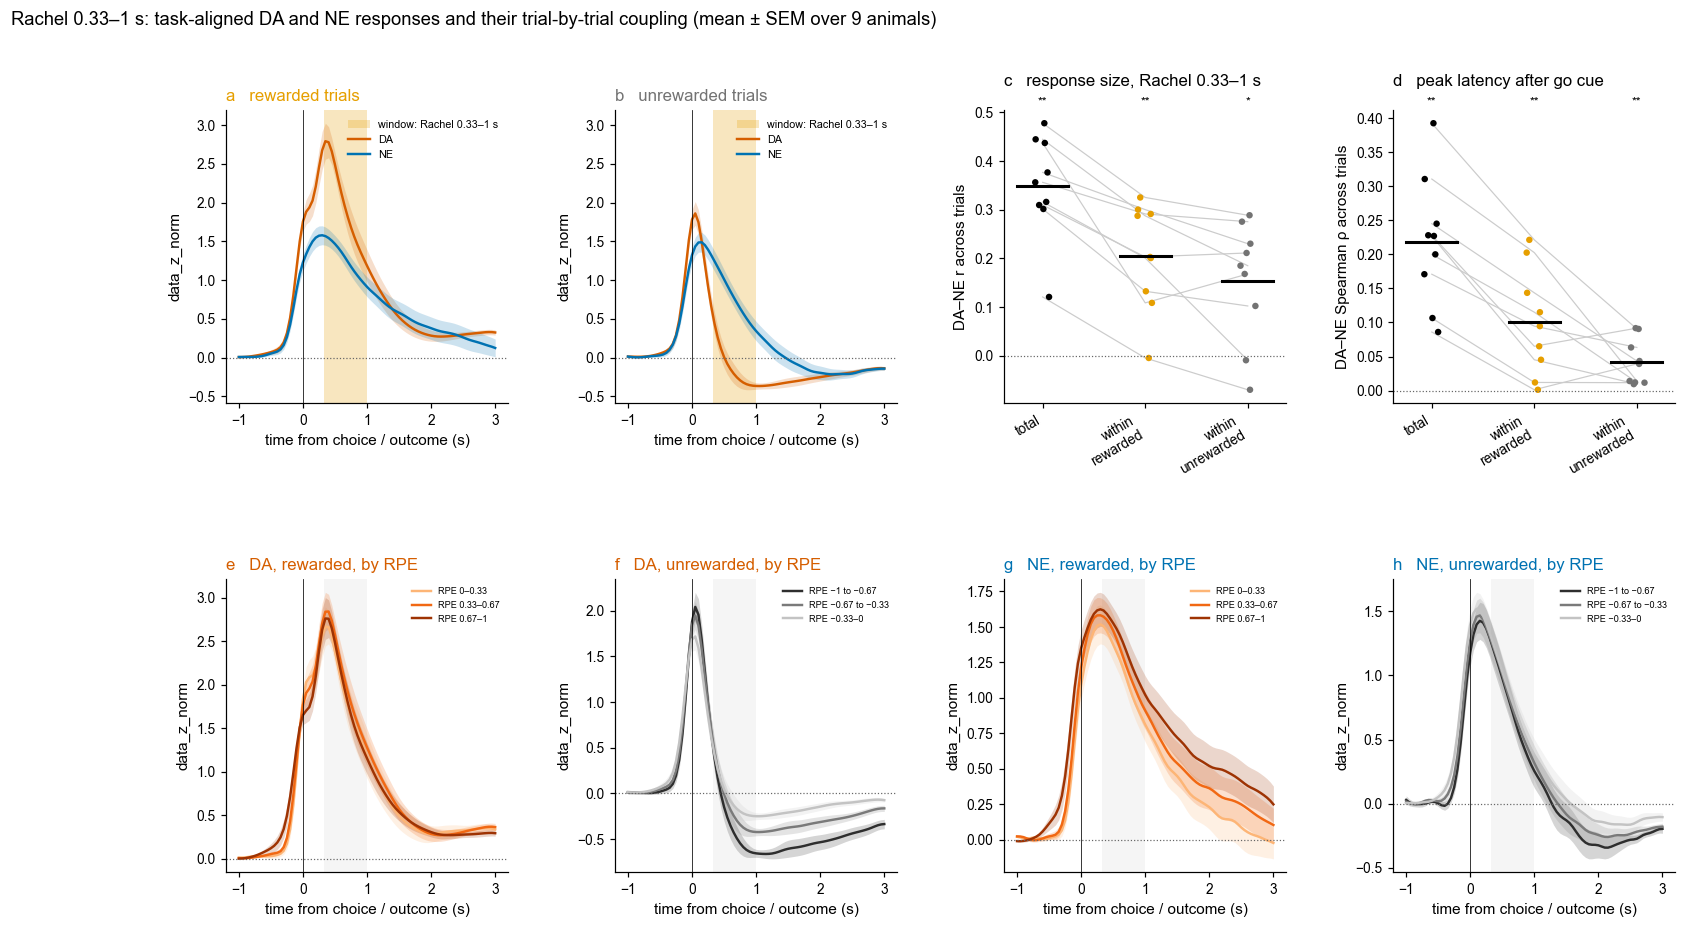

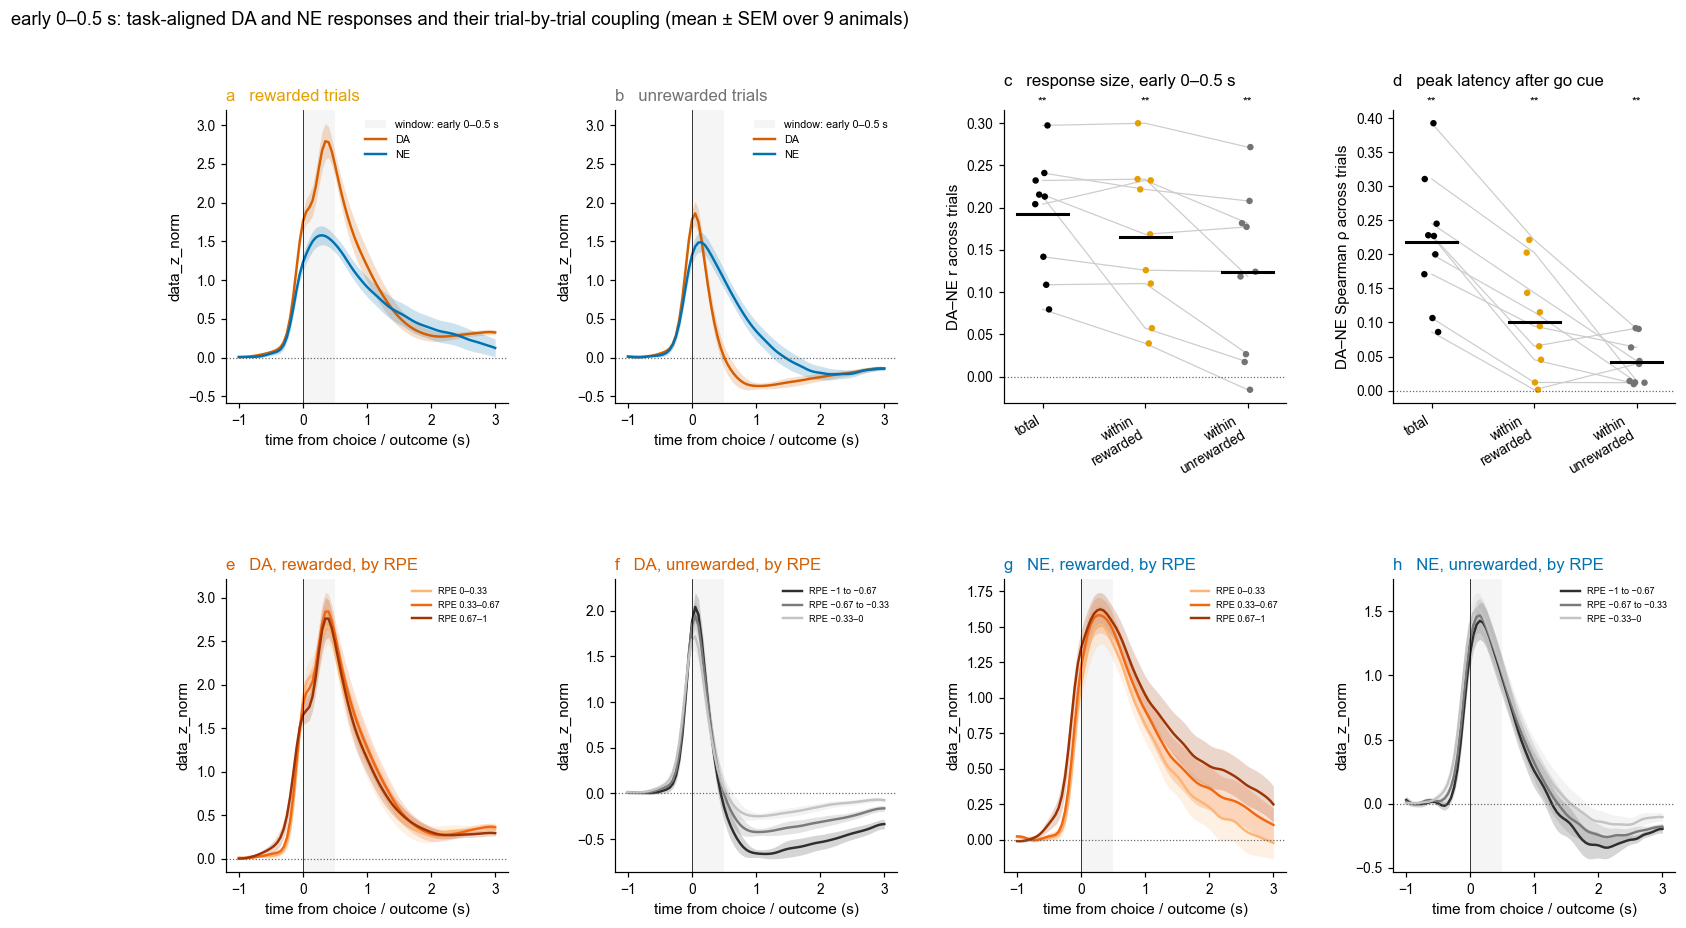

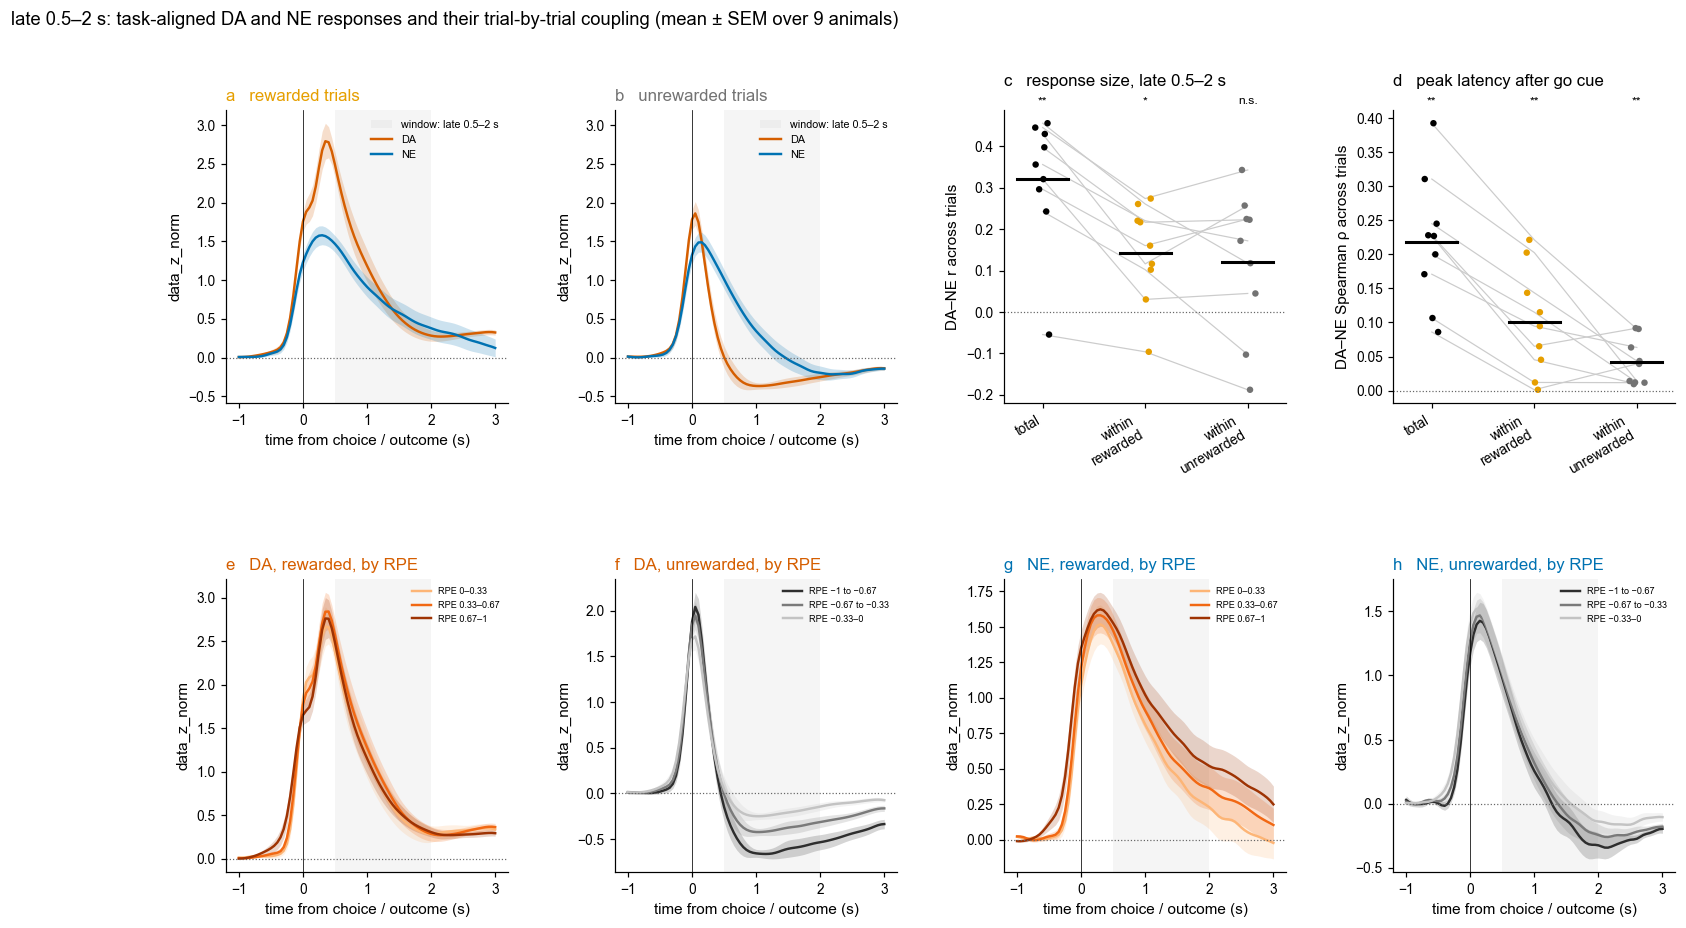

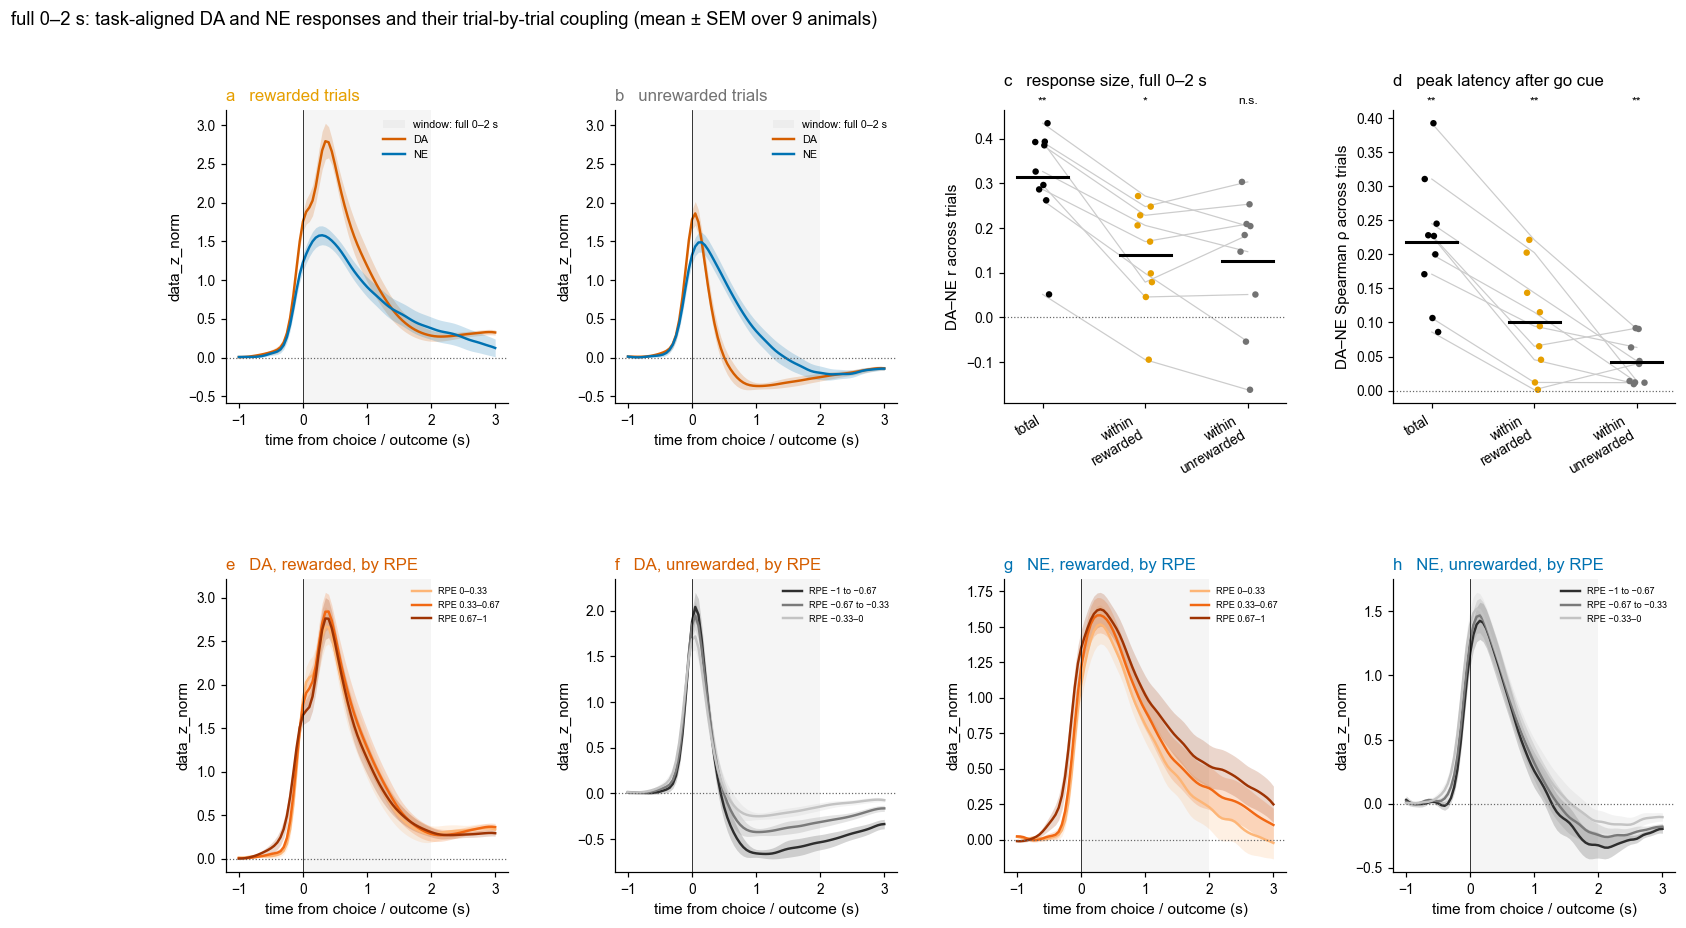

In [10]:
def make_fig3(w):
    a, b = WINDOWS[w]
    fig = plt.figure(figsize=(17, 9))
    gs = GridSpec(2, 4, figure=fig, hspace=0.6, wspace=0.38, top=0.88)

    ax0 = None
    for j, out in enumerate(("rewarded", "unrewarded")):
        ax = fig.add_subplot(gs[0, j], sharey=ax0)
        ax0 = ax0 or ax
        ax.axvspan(a, b, color=OUT_COLOR["rewarded"] if w == "rachel" else "0.85", alpha=0.25, lw=0,
                   label=f"window: {WINDOW_LABEL[w]}")
        for sig in ("da", "ne"):
            pu.plot_mean_sem(ax, PSTH_TIME, by_outcome[(sig, out)], SIG_COLOR[sig], sig.upper())
        ax.axvline(0, color="k", lw=0.5)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.set_xlabel("time from choice / outcome (s)")
        ax.set_ylabel("data_z_norm")
        ax.set_title(f"{'ab'[j]}   {out} trials", loc="left", color=OUT_COLOR[out])
        ax.legend(fontsize=7)
        style_ax(ax)

    ax = fig.add_subplot(gs[0, 2])
    pu.strip_by_measure(ax, size_corr, [f"{k}_{w}" for k in ("total", "rewarded", "unrewarded")],
                 ["total", "within\nrewarded", "within\nunrewarded"],
                 [TOTAL_COLOR, OUT_COLOR["rewarded"], OUT_COLOR["unrewarded"]],
                 "DA–NE r across trials", title=f"c   response size, {WINDOW_LABEL[w]}")
    ax = fig.add_subplot(gs[0, 3])
    pu.strip_by_measure(ax, lat_corr, ["total", "rewarded", "unrewarded"],
                 ["total", "within\nrewarded", "within\nunrewarded"],
                 [TOTAL_COLOR, OUT_COLOR["rewarded"], OUT_COLOR["unrewarded"]],
                 "DA–NE Spearman ρ across trials", title="d   peak latency after go cue")

    for j, (sig, out) in enumerate([(s, o) for s in ("da", "ne") for o in ("rewarded", "unrewarded")]):
        ax = fig.add_subplot(gs[1, j])
        ax.axvspan(a, b, color="0.85", alpha=0.25, lw=0)
        for k, q in enumerate(RPE_ORDER[out]):
            if (sig, (out, q)) in by_rpe:
                pu.plot_mean_sem(ax, PSTH_TIME, by_rpe[(sig, (out, q))], RPE_BIN_COLOR[out][k],
                            RPE_RANGE[(out, q)])
        ax.axvline(0, color="k", lw=0.5)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.set_xlabel("time from choice / outcome (s)")
        ax.set_ylabel("data_z_norm")
        ax.set_title(f"{'efgh'[j]}   {sig.upper()}, {out}, by RPE", loc="left", color=SIG_COLOR[sig])
        ax.legend(fontsize=6)
        style_ax(ax)
    fig.suptitle(f"{WINDOW_LABEL[w]}: task-aligned DA and NE responses and their "
                 f"trial-by-trial coupling (mean ± SEM over {N_ANIMALS} animals)", x=0.01, ha="left")
    save_fig(fig, f"fip_15_task_{w}", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()


for w in WINDOWS:
    make_fig3(w)

## 4. Numbers

One row per measure: mean of animal means, Wilcoxon p against zero, animals positive, and the
fraction of sessions with p < 0.05.

In [11]:
def row(section, measure, df, col, p=None):
    # animal means of a per-session column: mean, Wilcoxon p against 0, animals positive, and the
    # fraction of sessions with p < 0.05 where a per-session test exists
    v = df.groupby("subject")[col].mean()
    m, pv, n = st.wilcoxon_animals(v)
    out = dict(section=section, measure=measure, mean=round(m, 3), p=round(pv, 4),
               animals_positive=f"{int((v > 0).sum())}/{n}", sessions_p_lt_05="")
    if p is not None:
        d = df[[col, p]].dropna()
        out["sessions_p_lt_05"] = f"{int((d[p] < 0.05).sum())}/{len(d)}"
    return out


S = []
for w in WINDOWS:
    for k in SPLITS:
        S.append(row("2", f"size r, {k}, {WINDOW_LABEL[w]}", size_sess, f"{k}_{w}", f"{k}_{w}_p"))
for k in SPLITS:
    S.append(row("2", f"latency ρ, {k}", lat_sess, k, f"{k}_p"))
S += [row("2", "NE − DA median latency, rewarded (s)", lat_sess, "ne_minus_da_rew"),
      row("2", "NE − DA median latency, unrewarded (s)", lat_sess, "ne_minus_da_unrew")]
pd.DataFrame(S).set_index(["section", "measure"])

mean       p animals_positive sessions_p_lt_05
section measure                                                                                
2       size r, total, Rachel 0.33–1 s          0.349  0.0039              9/9            93/97
        size r, rewarded, Rachel 0.33–1 s       0.205  0.0078              8/9            72/97
        size r, unrewarded, Rachel 0.33–1 s     0.153  0.0195              7/9            59/97
        size r, total, early 0–0.5 s            0.192  0.0039              9/9            75/97
        size r, rewarded, early 0–0.5 s         0.165  0.0039              9/9            62/97
        size r, unrewarded, early 0–0.5 s       0.123  0.0078              8/9            53/97
        size r, total, late 0.5–2 s             0.321  0.0078              8/9            91/97
        size r, rewarded, late 0.5–2 s          0.143  0.0117              8/9            60/97
        size r, unrewarded, late 0.5–2 s        0.121  0.0742              7/9            63/97
        size r, total, full 0–2 s               0.314  0.0039              9/9            94/97
        size r, rewarded, full 0–2 s            0.139  0.0195              8/9            62/97
        size r, unrewarded, full 0–2 s          0.126  0.0547              7/9            61/97
        latency ρ, total                        0.218  0.0039              9/9            67/97
        latency ρ, rewarded                     0.100  0.0039              9/9            25/97
        latency ρ, unrewarded                   0.042  0.0039              9/9            14/97
        NE − DA median latency, rewarded (s)    0.017  0.7344              4/9                 
        NE − DA median latency, unrewarded (s)  0.157  0.0039              9/9